# Homework – Line Plot Visualization
## Smart Logistics Tracking System
**MO-IT148 | Blockchain and IoT Integration**

This notebook loads the cleaned IoT data and generates a line plot
of sensor readings over time, colored and filterable by sensor type (data_type).

---
### Step 1 – Load Cleaned IoT Data

In [1]:
import pandas as pd

# Load cleaned IoT data (output from Week 6)
df = pd.read_csv('cleaned_iot_data.csv')

# Convert timestamp column to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Display first few rows to verify data
print('✅ Cleaned IoT data loaded successfully!')
print(f'   Total records  : {len(df)}')
print(f'   Sensor types   : {df["data_type"].unique().tolist()}')
print(f'   Date range     : {df["timestamp"].min()} → {df["timestamp"].max()}')
print()
print(df.head())

✅ Cleaned IoT data loaded successfully!
   Total records  : 100
   Sensor types   : ['GPS', 'Temperature', 'Humidity']
   Date range     : 2026-01-01 01:30:10 → 2026-01-10 22:42:09

            timestamp device_id  package_id    data_type  \
0 2026-01-01 01:30:10    RFID_0        1055          GPS   
1 2026-01-01 02:30:22    RFID_1        1066          GPS   
2 2026-01-01 03:28:12    RFID_2        1001          GPS   
3 2026-01-01 04:30:02    RFID_3        1081  Temperature   
4 2026-01-01 10:44:47    RFID_4        1086  Temperature   

             data_value  numeric_value      status   latitude   longitude  
0  14.949141,124.334215      14.949141     Delayed  14.949141  124.334215  
1  10.528973,124.910757      10.528973   Delivered  10.528973  124.910757  
2  11.412766,124.552706      11.412766  In Transit  11.412766  124.552706  
3                 5.15C       5.150000     Delayed  10.614545  123.218513  
4                 7.31C       7.310000   Delivered  12.170094  121.315296  


---
### Step 2 – Line Plot: All Sensor Types

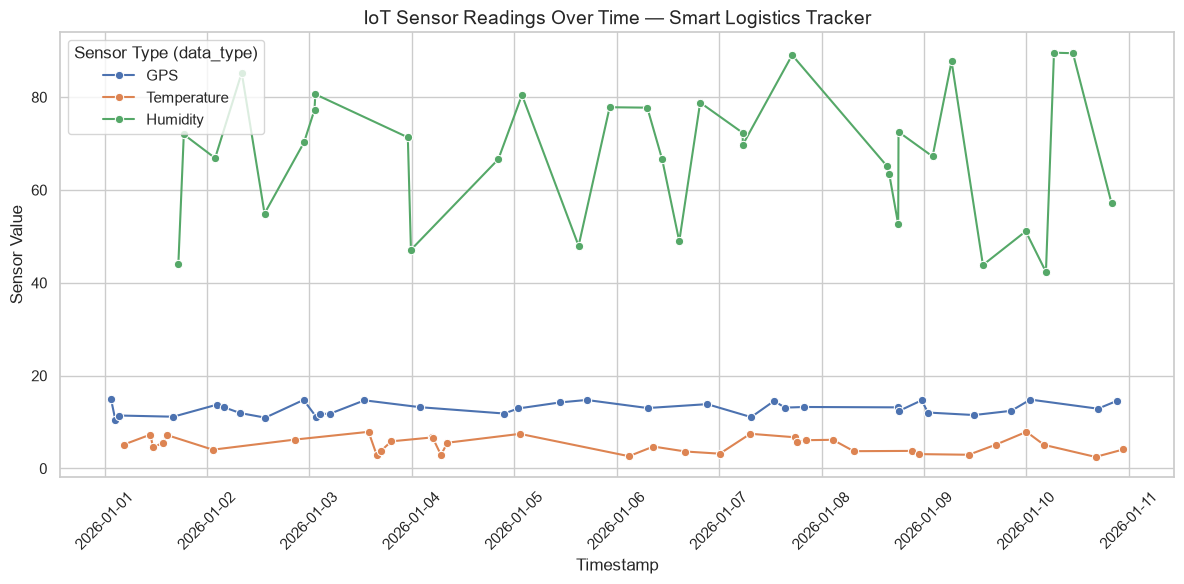

✅ Line plot saved as line_plot_all_sensors.png


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

plt.figure(figsize=(12, 6))

# Line plot colored by data_type (sensor type filter)
sns.lineplot(
    x=df['timestamp'],
    y=df['numeric_value'],
    hue=df['data_type'],
    marker='o'
)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add title and labels
plt.title('IoT Sensor Readings Over Time — Smart Logistics Tracker', fontsize=14)
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel('Sensor Value', fontsize=12)

# Show legend (acts as sensor type filter indicator)
plt.legend(title='Sensor Type (data_type)')

plt.tight_layout()
plt.savefig('line_plot_all_sensors.png', dpi=150)
plt.show()

print('✅ Line plot saved as line_plot_all_sensors.png')

---
### Step 3 – Sensor Type Filter (Individual Plots)

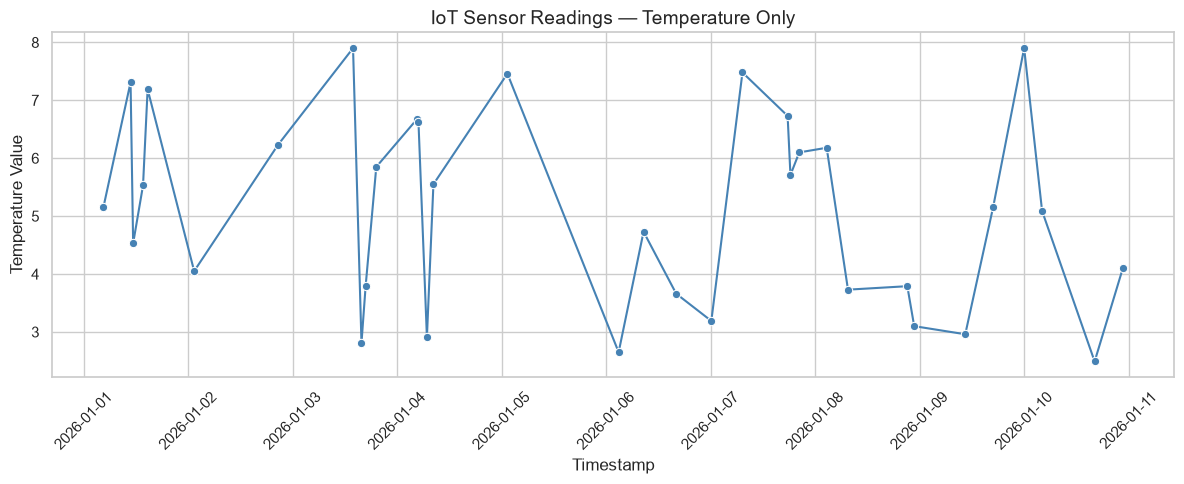

✅ Filtered plot saved: line_plot_temperature.png
   Records shown: 34 (Temperature only)


In [3]:
# ── SENSOR TYPE FILTER ───────────────────────────────────────────────
# Change FILTER_SENSOR to view a specific sensor type
# Options: 'Temperature' | 'Humidity' | 'GPS'
FILTER_SENSOR = 'Temperature'
# ─────────────────────────────────────────────────────────────────────

df_filtered = df[df['data_type'] == FILTER_SENSOR]

plt.figure(figsize=(12, 5))
sns.lineplot(
    x=df_filtered['timestamp'],
    y=df_filtered['numeric_value'],
    marker='o',
    color='steelblue'
)

plt.xticks(rotation=45)
plt.title(f'IoT Sensor Readings — {FILTER_SENSOR} Only', fontsize=14)
plt.xlabel('Timestamp', fontsize=12)
plt.ylabel(f'{FILTER_SENSOR} Value', fontsize=12)
plt.tight_layout()
plt.savefig(f'line_plot_{FILTER_SENSOR.lower()}.png', dpi=150)
plt.show()

print(f'✅ Filtered plot saved: line_plot_{FILTER_SENSOR.lower()}.png')
print(f'   Records shown: {len(df_filtered)} ({FILTER_SENSOR} only)')